# Relatório Técnico: Classificação Automatizada de Lesões de Pele com Aprendizado Profundo
**Envolvido(s):** MARIA CLARA SILVA BRITO, MATHEUS VINÍCIUS SILVA FREIRE DE CASTRO
**Data:** 30 Junho de 2026  
**Contexto:** Desenvolvimento de Modelos Preditivos Baseados no Dataset HAM10000

A problematica central que será atacada nesse projeto é a alta a gravidade associadas às lesões de pele, com foco crítico no **Melanoma** sendo ela a forma mais agreciva de cancer de pele que surge atravez da proprias celulas que prodizem a melanina e **Carcinoma Basocelular** a forma mais comum que surge em areas com alta exposição ao sol, que mesmo comum tambem está entre as formas mais agressivas e letais de câncer de pele. O diagnóstico precoce dessas patologias é o fator determinante para a sobrevivência dos pacientes. 

Entretanto, a identificação visual humana de lesões dermatológicas é altamente complexa e demorada e dificil, exigindo anos de especialização e esta sujeita a variações de interpretação entre os profissionais. Então, notando a necessidade de diagnostico cada vez mais rapido esse projeto tenta criar um sistema de analise por meio de imagens capaz de diferenciar lesões malignas de benignas a partir de imagens medica, auxiliando na triagem rápida.

Mormente, a solução desse problema é de extrema importância para dois tipos de públicos principais: os **profissionais de saúde (dermatologistas e clínicos gerais)**, que ganham velocidade e uma pre analise para poder trabalhar com um norte inicial no tratamento e analise de um pasciente sendo esse projeto uma ferramenta de segunda opinião para reduzir o erro humano, e os **pacientes**, especialmente para regiões remotas ou com escassez de médicos especialistas, que passam a ter acesso a uma triagem ágil que acelera o encaminhamento para biópsias e analises mais profundas da condição clinica e uma possivel prevensão.

Para tentar resolver de forma mais precisa possivel foi usado especificamente de Aprendizado Profundo (*Deep Learning*), sendo indispensável nesse cenário porque abordagens tradicionais de computação baseadas em regras explícitas são incapazes de mapear a enorme variabilidade de texturas, bordas irregulares, assimetrias e tonalidades que caracterizam uma lesão maligna. Redes Neurais Convolucionais conseguem extrair features hierárquicas diretamente dos pixels, identificando padrões imperceptíveis ao olho humano de forma escalável.

Assim, o principal objetivo deste projeto é desenvolver, calibrar e avaliar um modelo de Redes Neurais que seja capaz de classificar imagens de lesões de pele em 7 categorias distintas e classificar da melhor forma possivel. Dessa maneira, alcançar o ponto ideal entre o equilíbrio do custo computacional e clínico, priorizando a **redução drástica de Falsos Negativos** para patologias malignas (Melanoma), garantindo que nenhum paciente com câncer saia do teste com um falso diagnóstico tentando não inviezar o modelo com alarmes de falsos positivos em exesso, mesmo que seja uma troca que foi necessaria ser feita para mantar o maximo de segurança para pascientes que seria marcados com falsos negativos.

In [2]:
from google.colab import drive
drive.mount('/content/drive') 

Mounted at /content/drive


Os dados que seram utiliados para treinar o modelo vem do dataset [HAM10000](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)(*Human Against Machine*), coletados de diferentes populações e adquiridos via biblioteca `kagglehub` (`kmader/skin-cancer-mnist-ham10000`). O dataset é composto por 10.015 imagens dermatoscópicas de alta qualidade, servindo de benchmark acadêmico global para o treinamento de IA em dermatologia.

A abordagem adotada baseia-se em **Aprendizado Profundo (Deep Learning)** utilizando a técnica de *Transfer Learning* (Aprendizado por Transferência)para reaproveitar características visuais pré-treinadas e otimizar e assim reduzir o tempo de treinamento e aprendizado supervisonado para prever um possivel diagnostico apartir de uma imagem de entrada e classificala dentre das 7 possiveis classes ou seja a tarefa executada é de **Classificação Multi-classe**, onde o modelo recebe uma imagem tridimensional de entrada e deve atribuir uma probabilidade para 7 classes mutuamente exclusivas.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


Durante a análise exploratória dos dados notamos que seria necessario fazer uma map para os valores de classificação do modelo para tornar mais legivel alem de um grande volume de dados desbalanceado da classe de tumores malignos ja que a classe que mais prevalecia de froma massiva de Nevos Benignos em detrimento de Melanomas e Carcinomas. Para tentar mitigar esse viés no treinamento, as seguintes etapas foram implementadas:

1. **Balanceamento via Matriz de Custo:** Utilizou-se a função `compute_class_weight` do `scikit-learn` para calcular pesos que fossem inversamente proporcionais a dimensão das classes ou seja quanto maior o valume de dados de uma determinada classe menor seria seu pesso e quanto menor o valume maior seria seu peso com isso o modelo seria penalizando quanto errasse menos volumozas durante o cálculo da função de perca.

2. **Pipeline de Dados Eficiente:** As imagens foram redimensionadas para o formato padrão de $224 \times 224 \times 3$ pixels que ja é a entra padrao para o modelo MobileNetV2 e estruturadas em objetos `tf.data.Dataset` com as funções `.shuffle()`, `.batch(32)` e `.prefetch(tf.data.AUTOTUNE)` para otimizar o consumo de memória.

3. **Normalização Espacial:** Os pixels foram normalizados para escalas estatísticas adequadas para garantir a estabilidade do gradiente.

In [4]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

dataset_path = '/kaggle/input/skin-cancer-mnist-ham10000'
csv_path = os.path.join(dataset_path, 'HAM10000_metadata.csv')

df = pd.read_csv(csv_path)

mapeamento_lesoes = { # map para melhorar a legibiliade principalmente na matriz de confução
    'nv': 'Nevo Melanocitico (Benigno)',
    'mel': 'Melanoma (Maligno)',
    'bcc': 'Carcinoma Basocelular (Maligno)',  
    'akiec': 'Queratose Actinica (Pre-Maligno)',
    'bkl': 'Queratose Benigna (Benigno)',
    'df': 'Dermatofibroma (Benigno)',
    'vasc': 'Lesao Vascular (Benigno)'
}

df['dx'] = df['dx'].map(mapeamento_lesoes)


# limpar as entradas q estao vazias e ma catalogadas



def caminho_da_imagem(image_id):
    nome_arquivo = f"{image_id}.jpg"
    caminho_part1 = os.path.join(dataset_path, 'ham10000_images_part_1', nome_arquivo)
    if os.path.exists(caminho_part1):
        return caminho_part1
    return os.path.join(dataset_path, 'ham10000_images_part_2', nome_arquivo)

df['image_path'] = df['image_id'].apply(caminho_da_imagem)
df['label_idx'] = pd.Categorical(df['dx']).codes

# divisao em train, val, test
train_df, val_df = train_test_split(df, test_size=0.4, random_state=42, stratify=df['label_idx'])
val_df, test_df = train_test_split(val_df, test_size=0.4, random_state=42, stratify=val_df['label_idx'])

maior_classe = df['dx'].value_counts().index[0]
print(f"Proporção no Treino:    {(train_df['dx'] == maior_classe).mean():.2%}")
print(f"Proporção na Validação: {(val_df['dx'] == maior_classe).mean():.2%}")
print(f"Proporção no Teste:     {(test_df['dx'] == maior_classe).mean():.2%}")


Proporção no Treino:    66.95%
Proporção na Validação: 66.96%
Proporção no Teste:     66.94%


O projeto explorou o paradigma de Transfer Learning utilizando duas arquiteturas distintas pré-treinadas no ImageNet:

1. **MobileNetV2:** Escolhido inicialmente por ser leve e eficiência ate mesmo para dispositivos móveis que opera com camadas de separadas em profundidade.
2. **EfficientNetB0, EfficientNetB3, EfficientNetB4:** Usados para comparação por serem modelos que sua arquitetura é mais pessada e  por sua técnica de redimensionamento composto e conexões de atenção interna tratam melhor as testuras das imagens e de como generalizar nesse casos de analise clinica.

In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# cria os pesos do modelo de forma inversamente proporcional
pesos = compute_class_weight( 
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx']
)


dicionario_pesos = dict(zip(np.unique(train_df['label_idx']), pesos))


In [6]:
import tensorflow as tf

def carregar_e_processar_classificacao(caminho_img, label): # processa as imagenes tranformando em vetores

    img_raw = tf.io.read_file(caminho_img)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0
    
    return img, label

batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_idx'].values))
train_dataset = train_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_df['image_path'].values, val_df['label_idx'].values))
val_dataset = val_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)


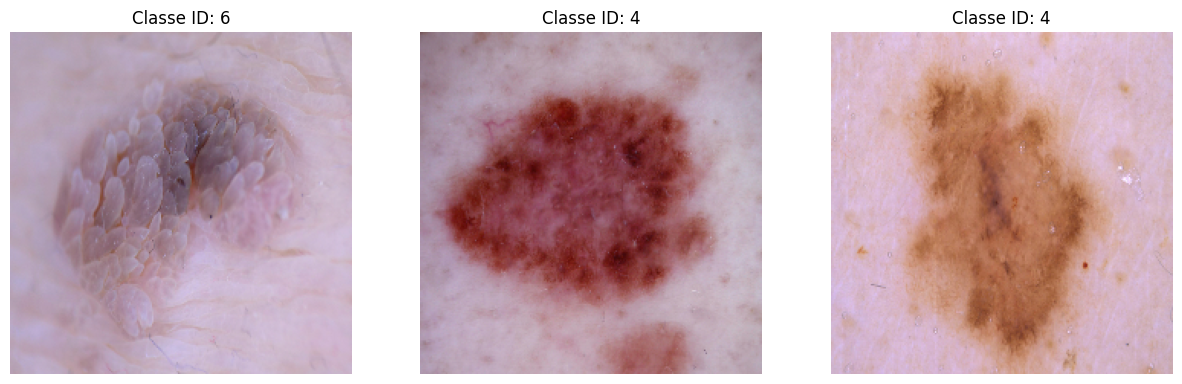

In [7]:
import matplotlib.pyplot as plt

for imagens_lote, labels_lote in train_dataset.take(1): # plot de froma aleatoria 3 imagens
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
    
    for i in range(3):

        axes[i].imshow(imagens_lote[i].numpy())
        

        classe_id = int(labels_lote[i])
        axes[i].set_title(f"Classe ID: {classe_id}")
        
        axes[i].axis('off')
        
    plt.show()


A classificação foi construída adicionando uma camada de `GlobalAveragePooling2D` que é uma camada totalmente conectada (`Dense`) que é para fazer uma transição mais suave entre os mapas de características em 3D e a camada final de classificação em 1D e passamos 256 neurônios com uma ativação do tipo relu, um `Dropout` que funciona como um controle de quantos neuronios de forma aleatoria estao aprendendo por epoca para reduzir overfitting que nos treinamentos iniciais estava constate e muito evidente, foi testado inicialmente com valor de 0.4 um valor medio entre o 0.3 e 0.5 que são os valores recomendados foi testado tambem com outros valores mas mesmo assim acontecendo overfitting quando removemos 60% dos neuronios durante o treino por epoca junto com o ajude dos pesos o modelo conseguiu generalizar de forma ainda mais eficiente com os dados de validação, e uma camada final `Softmax` de 7 neurônios que são nossas saida esperadas de classificação. 


In [8]:
train_df.min(), train_df.max()

(lesion_id                                             HAM_0000000
 image_id                                             ISIC_0024306
 dx                                Carcinoma Basocelular (Maligno)
 dx_type                                                  confocal
 age                                                           0.0
 sex                                                        female
 localization                                              abdomen
 image_path      /kaggle/input/skin-cancer-mnist-ham10000/ham10...
 label_idx                                                       0
 dtype: object,
 lesion_id                                             HAM_0007628
 image_id                                             ISIC_0034320
 dx                                    Queratose Benigna (Benigno)
 dx_type                                                     histo
 age                                                          85.0
 sex                                          

In [14]:
from keras import Input, layers, Model

x_in = Input(shape=(224, 224, 3))

x = layers.Flatten()(x_in)e

x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

x_out = layers.Dense(7, activation="softmax")(x)

model_tradicional = Model(inputs=x_in, outputs=x_out)
model_tradicional.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,276,423 (73.53 MB)

 Trainable params: 19,276,423 (73.53 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model_tradicional.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

In [24]:
final_training = True  
n_epochs = 5
batch_size = 32 

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 118s 586ms/step - accuracy: 0.6520 - loss: 1.0658 - val_accuracy: 0.6775 - val_loss: 1.0174
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 125s 599ms/step - accuracy: 0.6590 - loss: 1.0729 - val_accuracy: 0.6567 - val_loss: 1.0295
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 113s 560ms/step - accuracy: 0.6637 - loss: 1.0245 - val_accuracy: 0.6700 - val_loss: 1.0098
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 138s 557ms/step - accuracy: 0.6690 - loss: 1.0122 - val_accuracy: 0.6696 - val_loss: 1.0016
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 111s 564ms/step - accuracy: 0.6702 - loss: 0.9885 - val_accuracy: 0.6583 - val_loss: 1.0501


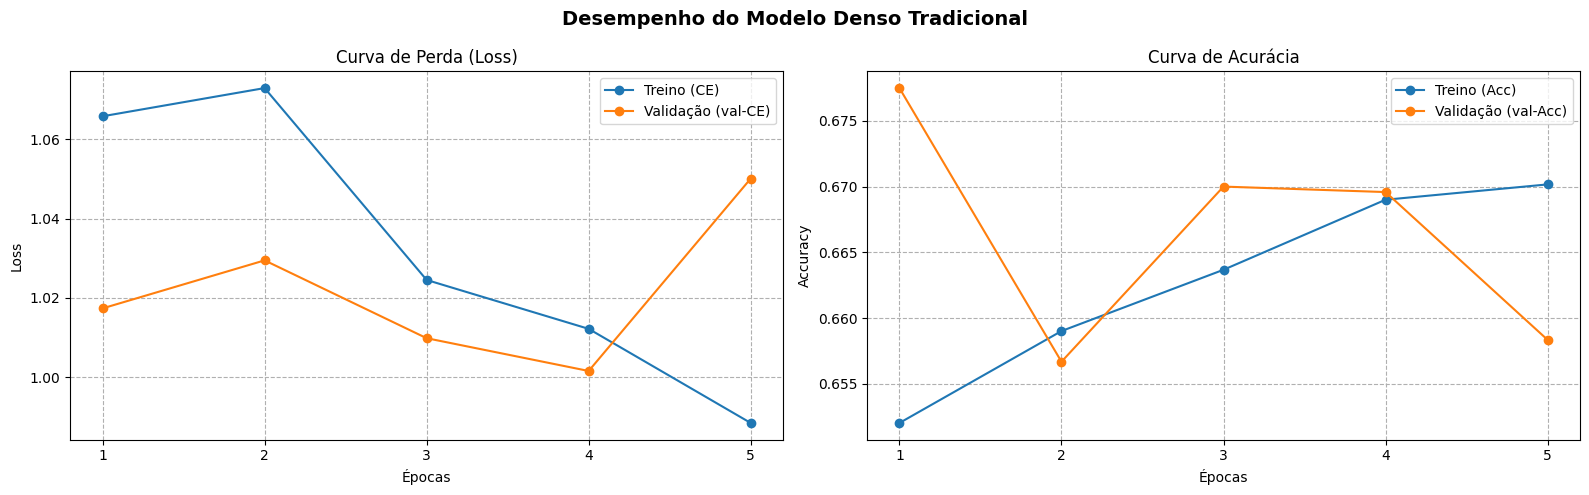

In [ ]:

if not final_training:
    
    
    report = model_tradicional.fit(
        train_dataset,  
        validation_data=val_dataset,
        epochs=n_epochs,
        batch_size=batch_size
    )

    loss = report.history['loss']
    acc = report.history['accuracy']

    val_loss = report.history['val_loss']
    val_acc = report.history['val_accuracy']

    epochs = np.arange(1, len(loss) + 1)  

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Desempenho do Modelo Denso Tradicional", fontsize=14, fontweight='bold')

    
    ax[0].plot(epochs, loss, label='Treino (CE)', marker='o')
    ax[0].plot(epochs, val_loss, label='Validação (val-CE)', marker='o')
    ax[0].set_title("Curva de Perda (Loss)")
    ax[0].set_ylabel("Loss")

    
    ax[1].plot(epochs, acc, label='Treino (Acc)', marker='o')
    ax[1].plot(epochs, val_acc, label='Validação (val-Acc)', marker='o')
    ax[1].set_title("Curva de Acurácia")
    ax[1].set_ylabel("Accuracy")

    
    for i in range(2):
        ax[i].set_xlabel("Épocas")
        ax[i].set_xticks(epochs)  
        ax[i].legend()
        ax[i].grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()

In [ ]:
if final_training:
    test_dataset = tf.data.Dataset.from_tensor_slices((test_df['image_path'].values, test_df['label_idx'].values))
    test_dataset = test_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)

    report = model_tradicional.fit(
        train_dataset,  
        epochs=n_epochs,
        batch_size=batch_size
    )

    # Coleta apenas as métricas existentes no treino final
    loss = report.history['loss']
    acc = report.history['accuracy']

    epochs = np.arange(1, len(loss) + 1)  

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Desempenho do Modelo Denso Tradicional (Treino Final)", fontsize=14, fontweight='bold')

    # Gráfico de Perda (Apenas Treino)
    ax[0].plot(epochs, loss, label='Treino (CE)', marker='o', color='firebrick')
    ax[0].set_title("Curva de Perda (Loss)")
    ax[0].set_ylabel("Loss")

    # Gráfico de Acurácia (Apenas Treino)
    ax[1].plot(epochs, acc, label='Treino (Acc)', marker='o', color='royalblue')
    ax[1].set_title("Curva de Acurácia")
    ax[1].set_ylabel("Accuracy")

    for i in range(2):
        ax[i].set_xlabel("Épocas")
        ax[i].set_xticks(epochs)  
        ax[i].legend()
        ax[i].grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 97s 482ms/step - accuracy: 0.6748 - loss: 0.9819
Epoch 2/5


In [ ]:
if final_training:
    
   
    ce, acc = model_tradicional.evaluate(test_dataset, batch_size)
    print(f"\nCE = {ce:.4f}, acc = {acc:.4f}\n")
if final_training:
    test_dataset = tf.data.Dataset.from_tensor_slices((test_df['image_path'].values, test_df['label_idx'].values))
    test_dataset = test_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)


    
    report = model_tradicional.fit(
        train_dataset,  
        epochs=n_epochs,
        batch_size=batch_size
    )

    loss = report.history['loss']
    acc = report.history['accuracy']

    val_loss = report.history['val_loss']
    val_acc = report.history['val_accuracy']

    epochs = np.arange(1, len(loss) + 1)  

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Desempenho do Modelo Denso Tradicional", fontsize=14, fontweight='bold')

    
    ax[0].plot(epochs, loss, label='Treino (CE)', marker='o')
    ax[0].plot(epochs, val_loss, label='Validação (val-CE)', marker='o')
    ax[0].set_title("Curva de Perda (Loss)")
    ax[0].set_ylabel("Loss")

    
    ax[1].plot(epochs, acc, label='Treino (Acc)', marker='o')
    ax[1].plot(epochs, val_acc, label='Validação (val-Acc)', marker='o')
    ax[1].set_title("Curva de Acurácia")
    ax[1].set_ylabel("Accuracy")

    
    for i in range(2):
        ax[i].set_xlabel("Épocas")
        ax[i].set_xticks(epochs)  
        ax[i].legend()
        ax[i].grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()
    y_pred = model_tradicional.predict(test_dataset)

    print("\ny-pred | y-test")
    print("---------------")

    for p, y in zip(y_pred[:10], test_dataset[:10]):

        print(f" {np.argmax(p)}  |  {np.argmax(y)}")


In [72]:
from tensorflow.keras import layers, Model, Input

inputs = Input(shape=(224, 224, 3))


base_model = tf.keras.applications.MobileNetV2( # inicia o modelo
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False



x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.6)(x)


outputs = layers.Dense(7, activation='softmax', name="output_classificacao")(x)

model = Model(inputs=inputs, outputs=outputs)


for k, v in dicionario_pesos.items():
    print(f"• Classe {k}: Peso {v:.2f}")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)


model.summary()

• Classe 0: Peso 2.79
• Classe 1: Peso 12.44
• Classe 2: Peso 10.10
• Classe 3: Peso 1.29
• Classe 4: Peso 0.21
• Classe 5: Peso 4.38
• Classe 6: Peso 1.30


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_classificacao (Dense)    │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 77s 238ms/step - accuracy: 0.6755 - loss: 0.9820 - val_accuracy: 0.7203 - val_loss: 0.7540
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 52s 183ms/step - accuracy: 0.7103 - loss: 0.8257 - val_accuracy: 0.7407 - val_loss: 0.6950
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 54s 182ms/step - accuracy: 0.7204 - loss: 0.7853 - val_accuracy: 0.7341 - val_loss: 0.6938
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 91s 220ms/step - accuracy: 0.7263 - loss: 0.7591 - val_accuracy: 0.7586 - val_loss: 0.6539
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 54s 186ms/step - accuracy: 0.7391 - loss: 0.7377 - val_accuracy: 0.7886 - val_loss: 0.6101
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 63s 225ms/step - accuracy: 0.7426 - loss: 0.7029 - val_accuracy: 0.7890 - val_loss: 0.5982
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 63s 225ms/step - accuracy: 0.7557 - loss: 0.6752 - val_accuracy: 0.7940 - val_loss: 0.5746
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 75s 198ms/step - accuracy: 0.7607 - loss: 0

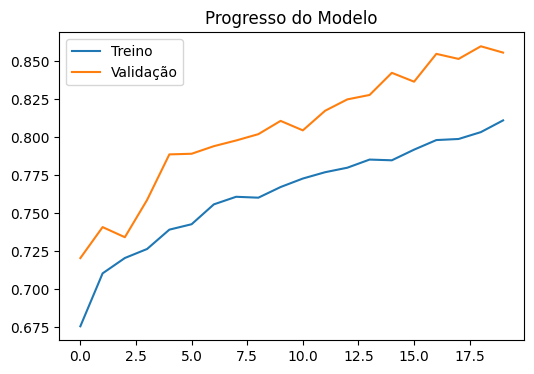

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, acc, label='Treino')
plt.plot(epochs_range, val_acc, label='Validação')
plt.title('Progresso do Modelo')
plt.legend()
plt.show()

In [ ]:

train_df = pd.concat([train_df, val_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_idx'].values))
train_dataset = train_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_df['image_path'].values, test_df['label_idx'].values))
test_dataset = test_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)


model.fit(train_dataset, epochs=3)

Epoch 1/3
338/338 ━━━━━━━━━━━━━━━━━━━━ 69s 192ms/step - accuracy: 0.8119 - loss: 0.5008
Epoch 2/3
338/338 ━━━━━━━━━━━━━━━━━━━━ 68s 151ms/step - accuracy: 0.8184 - loss: 0.4950
Epoch 3/3
338/338 ━━━━━━━━━━━━━━━━━━━━ 55s 151ms/step - accuracy: 0.8227 - loss: 0.4797



Para refinar ainda mais performance e simular o cenário prático de aplicação clínica, realizamos o uso de **Afinação de Threshold de Decisão (Limiar de Sensibilidade)** que apartir de um valor x de uma das classes de risco ou seja malignos ja é classificado com aquela classe mesmo que ela n seja a classe majoritaria para aumenta o numero assim de falsos positivos e reduzir o cenario que um pasciente tem o cancer e não foi diagnoticado mesmo que isso reduza nossa precisão e nossa acuracia global foi usado para avaliar o limiar de sensibilidade e o comportamento do modelo sob os limiares de **0.25**, **0.35** e **0.40** para as classes de maior risco.

Com isso, durante os testes o valode de 0.35 foi o que teve o melhor equilibrio na matris de confução

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step


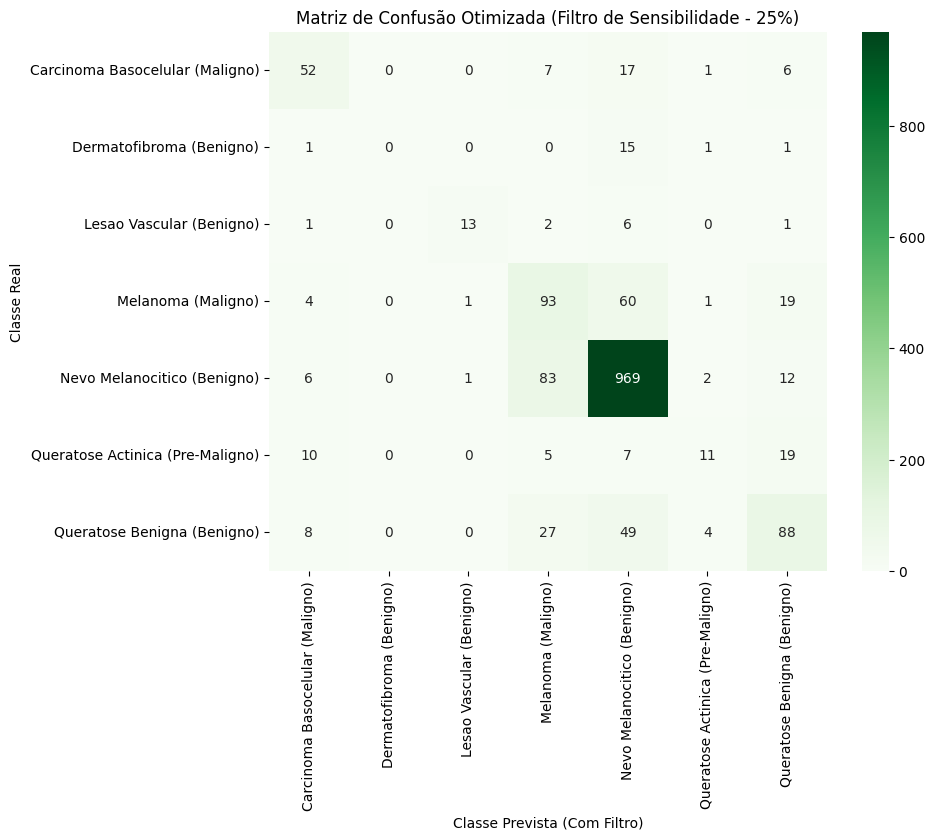

                                  precision    recall  f1-score   support

 Carcinoma Basocelular (Maligno)       0.63      0.63      0.63        83
        Dermatofibroma (Benigno)       0.00      0.00      0.00        18
        Lesao Vascular (Benigno)       0.87      0.57      0.68        23
              Melanoma (Maligno)       0.43      0.52      0.47       178
     Nevo Melanocitico (Benigno)       0.86      0.90      0.88      1073
Queratose Actinica (Pre-Maligno)       0.55      0.21      0.31        52
     Queratose Benigna (Benigno)       0.60      0.50      0.55       176

                        accuracy                           0.76      1603
                       macro avg       0.56      0.48      0.50      1603
                    weighted avg       0.75      0.76      0.76      1603



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

predicoes_prob = model.predict(test_dataset)

idx_carcinoma = 0  
idx_melanoma = 3   

predicoes_finais = []
sensibilide = 0.35 # valor de descição da sensibilidade do modelo pelo vetor de probablidade de cada amostra
# Aplica Threshold
for prob in predicoes_prob:
    if prob[idx_melanoma] > sensibilide:
        predicoes_finais.append(idx_melanoma)
    elif prob[idx_carcinoma] > sensibilide:
        predicoes_finais.append(idx_carcinoma)
    else:
        predicoes_finais.append(np.argmax(prob))

predicoes_finais = np.array(predicoes_finais)


y_true = np.concatenate([y for x, y in test_dataset], axis=0)


classes_nomes = pd.Categorical(df['dx']).categories.tolist()

cm = confusion_matrix(y_true, predicoes_finais)

# Plotar o Gráfico Otimizado
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes_nomes, yticklabels=classes_nomes)
plt.title('Matriz de Confusão Otimizada (Filtro de Sensibilidade - 25%)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Com Filtro)')
plt.show()

print(classification_report(y_true, predicoes_finais, target_names=classes_nomes))

A avaliação do modelo por meio do plot de matrizes de confusão sob diferentes limiares de sensibilidade mostrou um comportamento de:

* **Threshold em 0.25:** Tornou o modelo excessivamente paranoico. Embora tenha minimizado os Falsos Negativos de Melanoma para apenas 19 casos, gerou um volume impraticável de **284 alarmes falsos** em Nevos Benignos, derrubando a acurácia geral para 61%.

* **Threshold em 0.40:** Priorizou a limpeza visual dos acertos, elevando a acurácia geral para 73%, mas falhou clinicamente ao deixar passar **45 Melanomas sem detecção**, o que viola o princípio de segurança médica.

* **Threshold em 0.35:** Consagrou-se como a melhor configuração. Conseguiu capturar **111 Melanomas corretamente** (contra apenas 84 da abordagem sem filtro), cortou os Falsos Positivos nos Nevos pela metade (caindo de 284 para 132) e estabilizou uma acurácia geral madura de **71%**.

Classe Real: Nevo Melanocitico (Benigno)


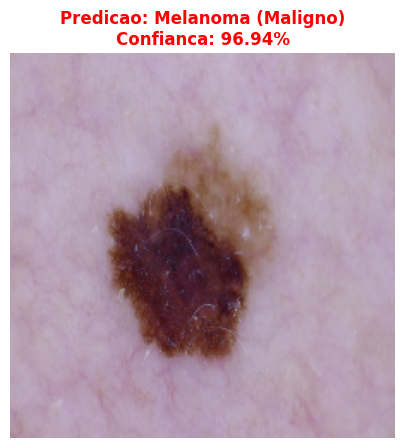

In [ ]:
def predizer_lesao(caminho_imagem_nova, modelo_treinado, lista_classes):
    
    img_raw = tf.io.read_file(caminho_imagem_nova)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0 
    
    img_lote = tf.expand_dims(img, axis=0)
    

    predicoes = modelo_treinado.predict(img_lote, verbose=0)
    
    indice_vencedor = np.argmax(predicoes[0])
    classe_vencedora = lista_classes[indice_vencedor]
    confianca = predicoes[0][indice_vencedor] * 100
    

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    
    
    if "Maligno" in classe_vencedora:
        cor_titulo = 'red'
    elif "Pre-Maligno" in classe_vencedora:
        cor_titulo = 'orange'
    else:
        cor_titulo = 'green'
        
    plt.title(f"Predicao: {classe_vencedora}\nConfianca: {confianca:.2f}%", 
              color=cor_titulo, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()
    
    return classe_vencedora, confianca


imagem = int(9)

test = test_df['image_path'].iloc[imagem] 
real = test_df['dx'].iloc[imagem]


classes_nomes = pd.Categorical(df['dx']).categories.tolist()

print(f"Classe Real: {real}")



classe_prevista, certeza = predizer_lesao(test, model, classes_nomes)

Os resultados alcançados com o modelo MobileNetV2 mostram que o modelo resolve **parcialmente** e de forma robusta o problema de velociade de classificar de forma precisa o e eficiente como ferramente clincia. Ele atua perfeitamente como uma ferramente de triagem inicial e chamar atenção de uma equipe clinica para mais teste e investigações clinicas o que pode auxiliar a diminuir erros médicos e auxiliar os medicos em suas analises. Contudo, como é relatado em todo o proheto este modelo não substitui a biópsia final  e nem muito o olhar clinico de um medico sobre as amostras. Assim, devendo ser rotulado estritamente como um Sistema de Suporte à Decisão Clínica ou usado pela pupulação para ter cuidados e chamar atenção para buscar ajudar medica.

In [ ]:
from google.colab import files

model.save_weights("pesos_skin_cancer.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>